# Example of Assignment 2

The idea behind assignment 2 is to use develop two ML models which recognizes emotions from images (sad face, happy, surprised, etc.). In order to achieve this, there are a few technical challenges that should be tackle, such as data imbalance, choosing the right features for the datastet, normalization strategies, etc. 

This notebook provides a basic example of a pipeline that a random forest with landmarks and evaluates the model to compute the confusion matrix, (balanced)accuracy and F1 macro.

### Loading and perform feature extraction on the dataset

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

Now we compute the class weights for the training set

In [6]:
csv_file = './data/fer2013_train.csv'
model_file = "./models/rf_fer_model_landmarks.pkl"

### Loading the data

In [7]:
###############################
# Computing class weights
##############################
from sklearn.utils.class_weight import compute_class_weight

trai_df = pd.read_csv(csv_file)

# Computing class weights for unbalanced dataset
labelsTrain = trai_df['emotion'].values
cw = compute_class_weight(
    class_weight="balanced", classes=np.unique(labelsTrain), y=labelsTrain)
#class_weights = {0:cw[0],1:cw[1],2:cw[2], 3:cw[3], 4:cw[4], 5:cw[5], 6:cw[6]}

### This is an example of a feature extraction pipeline
For this simple baseline model, we use a simple feature extraction pipeline with landmarks

In [8]:
import dlib 

# Importing dlib's landmark detector
# Dlib landmarks from: 
#   https://github.com/davisking/dlib-models/blob/master/shape_predictor_68_face_landmarks.dat.bz2
landmDet = dlib.shape_predictor("faceAndLandmarkModels/shape_predictor_68_face_landmarks_GTX.dat")

# Initialize scaler and classifier
scaler = StandardScaler()

# Track if scaler is fitted
scaler_fitted = False

def extractLandmarksFER(images):
    face_rects = dlib.rectangle(left=1, top=1, right=47, bottom=47)
    x1 = face_rects.left() 
    y1 = face_rects.top() 
    x2 = face_rects.right() 
    y2 = face_rects.bottom()

    landm = []
    for img in images:
        la = landmDet(img.astype(np.uint8), face_rects)

        # This works better if the standard scaler is not usec
        la2 = np.asarray( np.matrix([
            [
                (p.x-0.5*(x2-x1))/(x2-x1), (p.y-0.5*(y2-y1))/(y2-y1)
            ] for p in la.parts()])).astype(np.float32)
        la2 -= np.mean(la2, axis=0, keepdims=True)
        la2 /= np.max(np.abs(la2), axis=0, keepdims=True)

        landm.append(la2.flatten())
    feats = np.stack(landm)
    return(feats)

# Loading the images
images = np.array(
        [np.fromstring(pixels, sep=' ').reshape(48, 48) for pixels in trai_df['pixels']])
feats = extractLandmarksFER(images)

images = None

### Evaluating the results

In [9]:
from sklearn.ensemble import RandomForestClassifier
import joblib


rf = RandomForestClassifier(
    n_estimators=300,       # Number of trees
    max_depth=11,           # Allow trees to grow fully
    max_features='sqrt',   # Use sqrt(features) for splitting
    random_state=42,
    n_jobs=-1,             # Use all available CPU cores 
    #class_weight= "balanced", #class_weights,
    criterion="entropy",
)


rf.fit(feats, trai_df['emotion'].values)

joblib.dump(rf, model_file)
print(f"Model saved to {model_file}")

Model saved to ./models/rf_fer_model_landmarks.pkl


Finally, now that we have the trained models, we perfom the performance measurements in the validation set

Accuracy: 0.44
Balanced accuracy: 0.37
Macro F1: 0.38


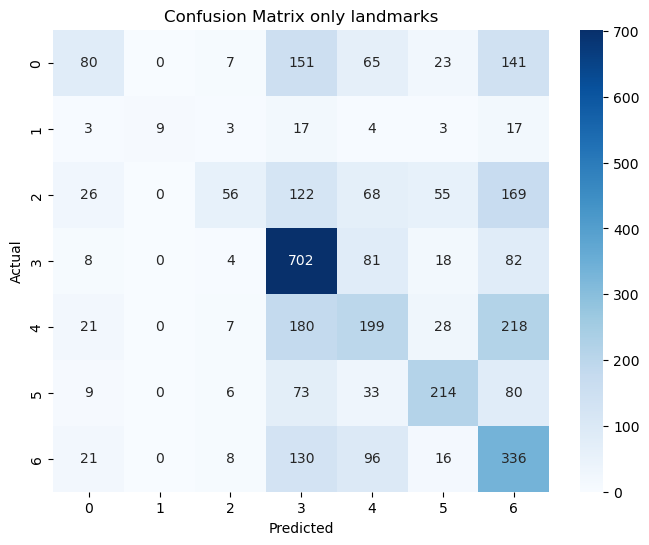

In [10]:
def preprocessingFer(dataFrame):
    # Convert pixel strings to 48x48 images
    images = np.array(
        [np.fromstring(pixels, sep=' ').reshape(48, 48) for pixels in dataFrame['pixels']])
    X =  extractLandmarksFER(images)
    y = dataFrame['emotion'].values
    return([X,y])


# Predict and evaluate
valid = pd.read_csv('./data/fer2013_validation.csv')
X_valid, y_valid = preprocessingFer(valid)

y_pred = rf.predict(X_valid)
accuracy = accuracy_score(y_valid, y_pred)
conf_matrix = confusion_matrix(y_valid, y_pred)

from sklearn.metrics import balanced_accuracy_score, f1_score
baccuracy = balanced_accuracy_score(y_valid, y_pred)
macro_f1 = f1_score(y_valid, y_pred, average='macro')


# Print results
print(f"Accuracy: {accuracy:.2f}")
print(f"Balanced accuracy: {baccuracy:.2f}")
print(f"Macro F1: {macro_f1:.2f}")


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix only landmarks")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
